<a href="https://colab.research.google.com/github/Charishmakongara/OptiCrop-Smart-Agricultural-Production-Optimization-Engine/blob/main/TRAINING/Crop_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OptiCrop - Smart Agricultural Production Optimization Engine

## Project Overview

OptiCrop is a Machine Learning based crop recommendation system that predicts the most suitable crop based on soil nutrients and environmental conditions such as Nitrogen (N), Phosphorus (P), Potassium (K), temperature, humidity, pH, and rainfall.

The project covers the complete machine learning pipeline including:

- Data Collection
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Data Visualization
- Machine Learning Model Building
- Model Evaluation
- Crop Recommendation Prediction

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [4]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


## Read Dataset

The crop recommendation dataset is loaded into the notebook using the Pandas `read_csv()` function. The dataset contains important agricultural features such as Nitrogen (N), Phosphorus (P), Potassium (K), temperature, humidity, pH, rainfall, and crop labels. The first five records are displayed using the `head()` function to understand the dataset structure and verify that the data has been loaded successfully.

In [5]:
import pandas as pd

df = pd.read_csv("/content/Crop_recommendation.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## Univariate Analysis

Univariate analysis is performed to understand the distribution of individual agricultural features in the crop recommendation dataset. Histograms are used to visualize the frequency and spread of each numerical variable, helping to identify the range, distribution, and patterns of the data.

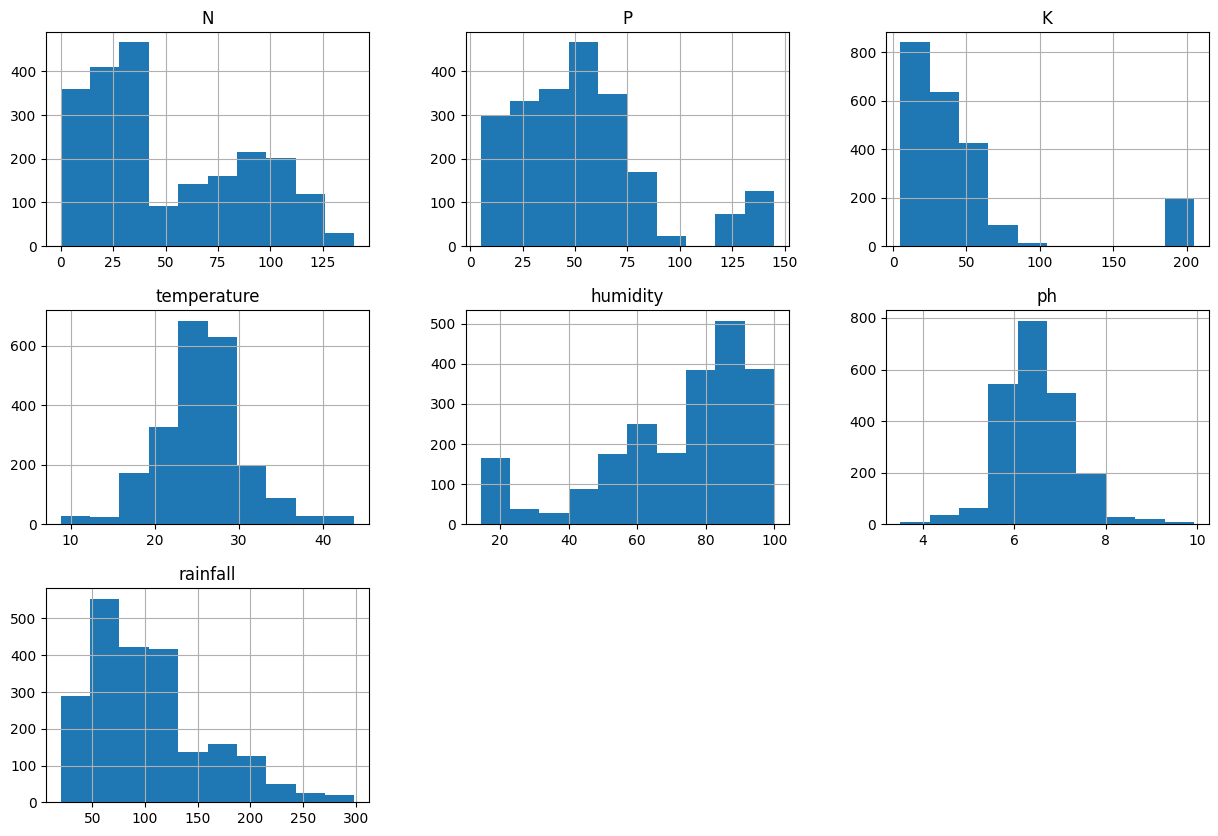

In [16]:
df.hist(figsize=(15,10))
plt.show()

## Bivariate Analysis

Bivariate analysis is performed to examine the relationship between two variables in the crop recommendation dataset. A scatter plot is used to visualize the relationship between humidity and crop labels, helping to understand how humidity varies across different crop categories.

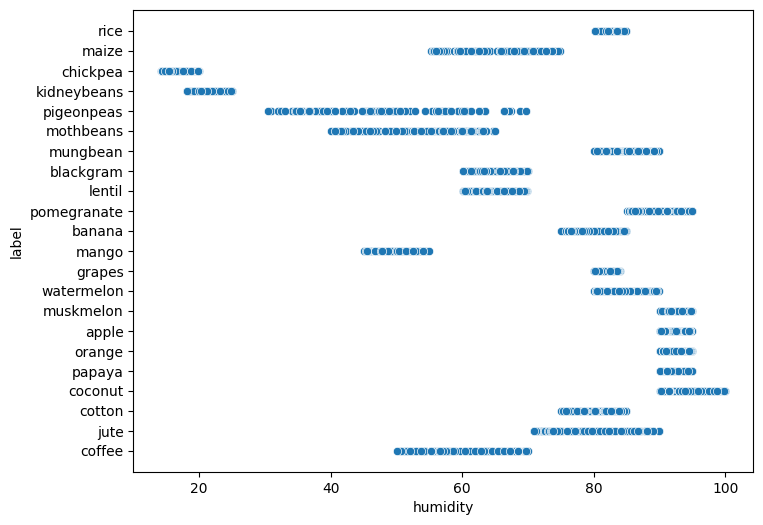

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['humidity'], y=df['label'])
plt.show()

## Multivariate Analysis

Multivariate analysis is performed to study multiple agricultural features simultaneously. A count plot is used to visualize the distribution of the dataset features, while descriptive statistics provide a summary of the dataset including count, mean, standard deviation, minimum, maximum, and quartile values. This analysis helps in understanding the overall characteristics of the agricultural dataset.

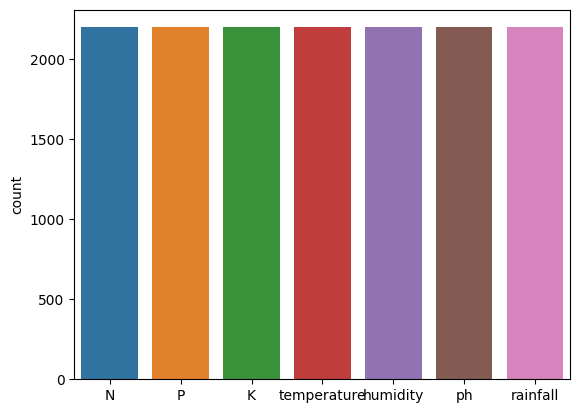

In [18]:
sns.countplot(df)
plt.show()

In [19]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


# Data Preprocessing

Data preprocessing is an essential step in building an accurate crop recommendation system. This phase focuses on preparing the agricultural dataset for machine learning by checking for missing values, handling outliers, extracting relevant seasonal crop information, and splitting the dataset into training and testing sets. These preprocessing techniques improve data quality, enhance model performance, and ensure reliable crop prediction results.

## Checking for Null Values

The dataset is examined for missing and null values before preprocessing and machine learning operations. Functions such as `df.shape`, `df.info()`, and `df.isnull().sum()` are used to analyze dataset structure, data types, and missing records. This step ensures clean and reliable agricultural data for accurate crop prediction.

In [20]:
df.isnull().sum()

df.shape

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


## Handling Outliers

Outliers are identified using boxplots and the Interquartile Range (IQR) method. Upper and lower bounds are calculated to detect abnormal observations, and appropriate filtering is applied to improve data quality and model performance.

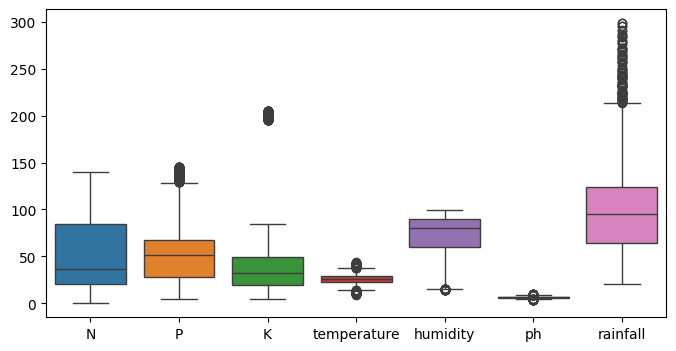

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(data=df)
plt.show()

In [22]:
Q1 = df["P"].quantile(0.25)
Q3 = df["P"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["P"] >= lower) & (df["P"] <= upper)]

## Extracting Seasonal Crops

The dataset is analyzed based on seasonal environmental conditions such as temperature, humidity, and rainfall. Crops are categorized into Summer, Winter, and Rainy seasons to understand their cultivation patterns and generate season-based agricultural insights.

In [23]:
print("Summer crops")
print(df[(df["temperature"]>30) & (df["humidity"]>50)]["label"].unique())

print("--------------------------------")

print("Winter crops")
print(df[(df["temperature"]<20) & (df["humidity"]>30)]["label"].unique())

print("--------------------------------")

print("Rainy crops")
print(df[(df["rainfall"]>200) & (df["humidity"]>50)]["label"].unique())

Summer crops
['pigeonpeas' 'mothbeans' 'blackgram' 'mango' 'grapes' 'orange' 'papaya']
--------------------------------
Winter crops
['maize' 'pigeonpeas' 'lentil' 'pomegranate' 'grapes' 'orange']
--------------------------------
Rainy crops
['rice' 'papaya' 'coconut']


## Splitting Data into Train and Test Sets

The dataset is divided into feature variables (X) and target variable (y). The `train_test_split()` function from Scikit-learn is used to split the dataset into training and testing sets. This step helps evaluate model performance and improves prediction reliability on unseen data.

In [7]:
from sklearn.model_selection import train_test_split

y = df["label"]
X = df.drop("label", axis=1)

print("Shape of x", X.shape)
print("Shape of y", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print("The shape of X train", X_train.shape)
print("The shape of X test", X_test.shape)
print("The shape of y train", y_train.shape)
print("The shape of y test", y_test.shape)

Shape of x (2200, 7)
Shape of y (2200,)
The shape of X train (1760, 7)
The shape of X test (440, 7)
The shape of y train (1760,)
The shape of y test (440,)


# Model Building

In this phase, machine learning models are trained using the crop recommendation dataset. The trained model is evaluated based on prediction accuracy, and the best-performing model is saved for deployment in the web application.

In [9]:
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

import pickle

## K-Means Clustering

K-Means Clustering is an unsupervised machine learning algorithm used to group similar agricultural patterns based on environmental features. The Elbow Method is applied to determine the optimal number of clusters by analyzing the Within Cluster Sum of Squares (WCSS). The model is trained using the `fit()` and `fit_predict()` methods to identify meaningful crop groupings and similar agricultural conditions within the dataset.

In [13]:
X = df.drop("label", axis=1)

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

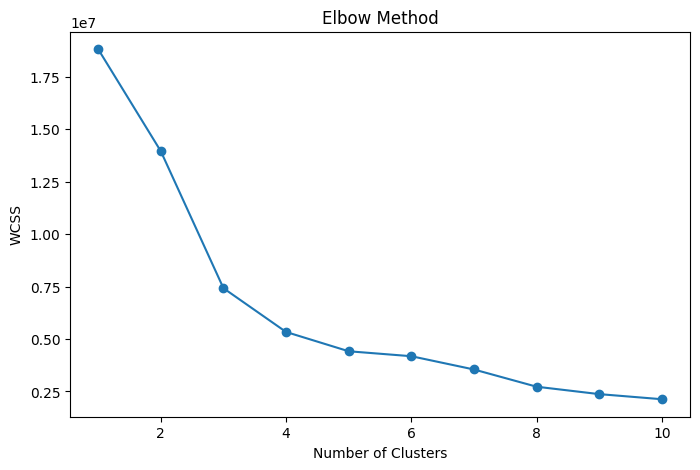

In [14]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [12]:
km = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)

y_means = km.fit_predict(X)

a = df['label']

y_means = pd.DataFrame(y_means)

z = pd.concat([y_means, a], axis=1)

z = z.rename(columns={0:'Cluster'})

In [ ]:
print("Lets check the results after applying the K-Means Clustering analysis\n")

print("Crops in First Cluster:", z[z['Cluster']==0]['label'].unique())
print("------------------------------------------------------------")

print("Crops in Second Cluster:", z[z['Cluster']==1]['label'].unique())
print("------------------------------------------------------------")

print("Crops in Third Cluster:", z[z['Cluster']==2]['label'].unique())
print("------------------------------------------------------------")

print("Crops in Fourth Cluster:", z[z['Cluster']==3]['label'].unique())

Lets check the results after applying the K-Means Clustering analysis

Crops in First Cluster: ['grapes' 'apple']
------------------------------------------------------------
Crops in Second Cluster: ['maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans' 'mungbean'
 'blackgram' 'lentil' 'pomegranate' 'mango' 'orange' 'papaya' 'coconut']
------------------------------------------------------------
Crops in Third Cluster: ['maize' 'banana' 'watermelon' 'muskmelon' 'papaya' 'cotton' 'coffee']
------------------------------------------------------------
Crops in Fourth Cluster: ['rice' 'pigeonpeas' 'papaya' 'coconut' 'jute' 'coffee']


## Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for crop prediction based on agricultural environmental features. The model is trained using the `fit()` method and predictions are generated using the `predict()` function. Model performance is evaluated to analyze prediction accuracy and crop recommendation capability.

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

model

LogisticRegression(max_iter=1000)

## Evaluating Model Performance and Saving the Best Model

The trained Logistic Regression model is evaluated using important classification metrics such as Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC Score. These metrics help identify the model that provides the most accurate and reliable predictions for the dataset.

After evaluating the performance of all trained models, the best-performing model is selected based on its overall classification results and generalization capability. The finalized model is then serialized using `pickle.dump()` and stored as **model.pkl** so that it can be reused without retraining during deployment in the Flask web application.

In [26]:
from sklearn.metrics import classification_report

cr = classification_report(y_test, y_pred)

print(cr)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        18
   blackgram       0.87      0.91      0.89        22
    chickpea       1.00      1.00      1.00        23
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        17
      cotton       0.94      1.00      0.97        16
      grapes       1.00      1.00      1.00        18
        jute       0.87      0.95      0.91        21
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.82      0.82      0.82        17
       maize       1.00      0.94      0.97        18
       mango       1.00      1.00      1.00        21
   mothbeans       0.95      0.84      0.89        25
    mungbean       1.00      1.00      1.00        17
   muskmelon       0.96      1.00      0.98        23
      orange       1.00      1.00      1.00        23
      papaya       0.95    

In [27]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

## Predict the Best Crop Based on Given Parameters

The saved model is utilized to predict the most suitable crop based on the environmental and soil conditions provided by the user. Input features are collected and passed to the trained machine learning model using the `predict()` method.

The model processes these parameters and generates the best crop recommendation for the given conditions. This prediction helps farmers make informed agricultural decisions and improve crop productivity.

In [29]:
sample = [[100, 35, 40, 25, 64, 7, 160]]

sample = scaler.transform(sample)

prediction = model.predict(sample)

print("The suggested crop for given climatic condition is:", prediction)

The suggested crop for given climatic condition is: ['rice']


# Conclusion

The **OptiCrop Smart Agricultural Production Optimization Engine** was successfully developed using machine learning techniques to recommend the most suitable crop based on soil nutrients and environmental conditions. The project began with data collection and exploratory data analysis, followed by data preprocessing through handling missing values, treating outliers, performing feature selection, and splitting the dataset into training and testing sets.

K-Means Clustering was applied to identify similar agricultural patterns, while the Logistic Regression algorithm was trained to predict the most suitable crop. The model was evaluated using standard performance metrics, and the best-performing model was saved for deployment in the Flask web application. Finally, a user-friendly web interface was developed to allow users to provide agricultural parameters and receive crop recommendations instantly.

Overall, this project demonstrates how machine learning can support precision agriculture by improving crop selection, increasing productivity, and enabling data-driven farming decisions. In the future, the application can be enhanced by integrating real-time weather information, IoT sensor data, fertilizer recommendation, pest detection, and advanced machine learning models to further improve prediction accuracy and smart farming capabilities.